# Discrete Choice Model Interpretation & Business Recommendations 

Estimated Time: 2-4 hours 

__Background__

At Astrea, we use discrete choice models to help clients make data-driven portfolio decisions. A 
common challenge is answering "sourcing" questions: for example, if a product is discontinued, 
where will its sales volume go? Or, stated differently, understand the cannibalization effect of 
introducing a new product in a category. 

Your task is to analyze the output of a simple discrete choice model, interpret its implications, 
and propose improvements to better address sourcing questions. 
You’ll be using an Multinomial Logit model, where the utility U for each item j, represented as: 

Uj = β0  + β1 X1j + β2 X2j + ⋯ + βk Xkj 

Where βn is the nth coefficient, and Xnj is the jth item’s nth characteristic. 
In order to estimate the βn, we collected data from respondents that are exposed to trips 
(subsets of items) and have to declare which of those items they would choose. 

__Dataset & Model Output__

You are provided with: 

1. Two CSV files containing the results of a multinomial logit (MNL) model, one the model 
coefficients and the other, the respondents data to exposure to trips of items. 

2. A short Python script to generate predictions.

__Tasks__

1. Model Interpretation 

- Examine the model coefficients and explain what they indicate about consumer 
preferences. 

- Identify any potential concerns or inconsistencies in the output (e.g., extreme 
coefficients, unrealistic substitution patterns).


2. Business Implications 

- Suppose our client is considering discontinuing Product X (choose any item). 
Based on the model results, where do you expect its sales volume to shift? 

- What additional analyses or model enhancements would you recommend to 
improve sourcing predictions? 

3. Technical Recommendations 

- What limitations does a standard MNL model have in answering sourcing 
questions? 

- Suggest a potential improvement 

__Deliverable__

Submit a brief Jupyter Notebook or Python script containing: 

- Your analysis and interpretations in markdown/text cells. 

- Any relevant exploratory code (e.g., visualizations, basic calculations).

# DELIVERABLE

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [147]:
coefs = pd.read_csv('logit_coefficients.csv')
coefs = coefs.set_index('Variable').T.round(2)
coefs

Variable,const,price,brand_strength,quality_score
Coefficient,-3.29,-0.58,0.31,1.2


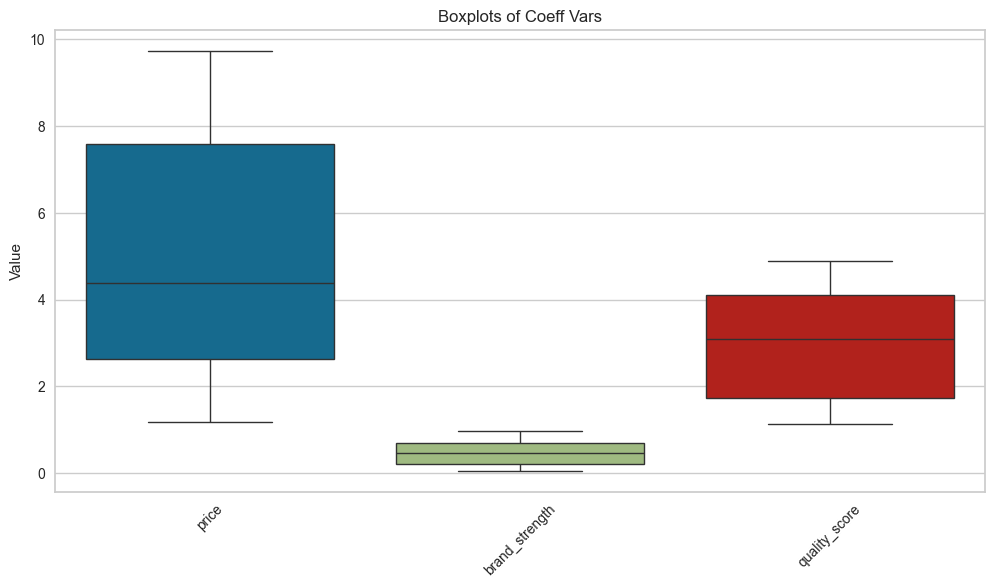

In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataframe (replace this with your actual data)
# df = pd.read_csv("your_data.csv")

# Exclude non-numeric columns (if any)
numeric_cols = df[['price', 'brand_strength', 'quality_score']]
# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_cols)

# Customize plot labels
plt.xticks(rotation=45)  # Rotate labels for readability
plt.title("Boxplots of Coeff Vars")
plt.ylabel("Value")

# Show the plot
plt.show()


In [149]:
coefs.T

,Coefficient
Variable,
const,-3.29
price,-0.58
brand_strength,0.31
quality_score,1.20


In [150]:
coefs

Variable,const,price,brand_strength,quality_score
Coefficient,-3.29,-0.58,0.31,1.2


In [151]:
numeric_cols_mean = pd.DataFrame(numeric_cols.mean().T)
numeric_cols_mean.columns = ['avg']

In [ ]:
numeric_cols_mean

,avg
Variable,
price,5.114813
brand_strength,0.455457
quality_score,2.956674


In [157]:
numeric_cols_mean = numeric_cols_mean.rename_axis("Variable")
merged = pd.merge(coefs.T, numeric_cols_mean,on='Variable')
merged['scaled_coeff'] = merged.Coefficient/ merged.avg*100
merged.round(2)

,Coefficient,avg,scaled_coeff
Variable,,,
price,-0.58,5.11,-11.34
brand_strength,0.31,0.46,68.06
quality_score,1.20,2.96,40.59


## 1. Model Interpretation 

#### Examine the model coefficients and explain what they indicate about consumer preferences. 

+ const (Intercept)	-3.29	Baseline utility when all features are zero. A negative value means consumers generally have a low probability of choosing a product unless features like brand strength, quality, or price increase the utility.

+ price	-0.58	Negative coefficient → Higher prices reduce the likelihood of selection (as expected). The absolute value of 0.58 means price has a moderate impact on choice.

+ brand_strength	0.31	Positive coefficient → A stronger brand increases the probability of choice. Notwithstanding it's smaller than the quality effect (1.2) the average value for the feature brand_strenght is much lower, suggesting consumers care more about brand_strength than anything else.

+ quality_score	1.2	Strongest positive effect → Consumers prefer higher quality, and this is the dominant factor driving choice.




### Identify any potential concerns or inconsistencies in the output (e.g., extreme coefficients, unrealistic substitution patterns).

In [ ]:
Considering coefficients adjusted by their respective means we can see that:
- sensitivity to price is relatively very low and that might not be realistic.
- 

In [55]:
df = pd.read_csv('synthetic_choice_data.csv')
df.head()

,respondent_id,trip_id,product_id,price,brand_strength,quality_score,group,choice
0,0,0,13,2.911052,0.948886,4.579309,0,0
1,0,0,5,2.403951,0.785176,3.650089,0,0
2,0,0,7,8.795585,0.514234,3.080272,0,0
3,0,0,10,1.185260,0.607545,4.878339,0,1
4,0,0,12,8.491984,0.065052,4.757996,0,0


In [56]:
# df.respondent_id.nunique()
df.shape

(75000, 8)

In [46]:
df.product_id.count()

75000

In [67]:
df.head()

,respondent_id,trip_id,product_id,price,brand_strength,quality_score,group,choice
0,0,0,13,2.911052,0.948886,4.579309,0,0
1,0,0,5,2.403951,0.785176,3.650089,0,0
2,0,0,7,8.795585,0.514234,3.080272,0,0
3,0,0,10,1.185260,0.607545,4.878339,0,1
4,0,0,12,8.491984,0.065052,4.757996,0,0


In [68]:
%run take-home-predict.py

   product_id  predicted_choice_prob
0           1               0.152508
1           2               0.315033
2           3               0.033762
3           4               0.102532
4           5               0.396165


In [69]:
predictions = pd.read_parquet('predictions.parquet')

In [72]:
predictions

,product_id,price,brand_strength,quality_score,const,predicted_choice_prob
0,1,5.0,0.3,3.0,1.0,0.152508
1,2,7.0,0.6,4.5,1.0,0.315033
2,3,6.5,0.2,2.5,1.0,0.033762
3,4,8.0,0.8,4.0,1.0,0.102532
4,5,4.5,0.5,3.5,1.0,0.396165


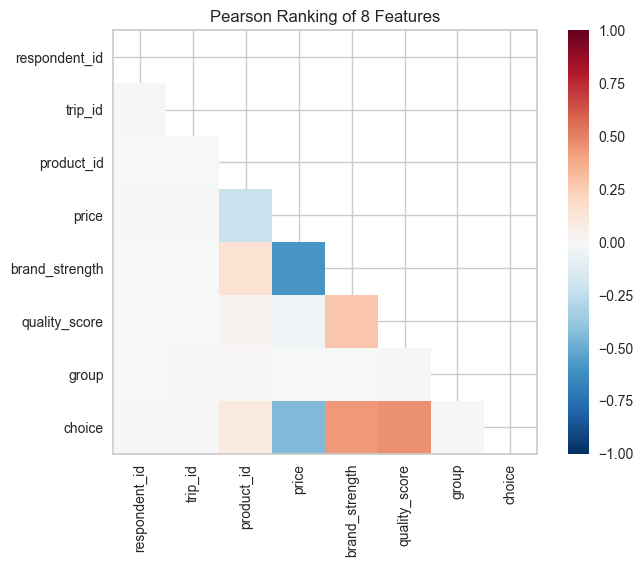

<Axes: title={'center': 'Pearson Ranking of 8 Features'}>

In [10]:
from yellowbrick.features import Rank2D

visualizer = Rank2D(algorithm="pearson")
visualizer.fit_transform(df)
visualizer.show()

Dataset Shape: (75000, 8)

Missing Values:
 respondent_id     0
trip_id           0
product_id        0
price             0
brand_strength    0
quality_score     0
group             0
choice            0
dtype: int64

Data Types:
 respondent_id       int64
trip_id             int64
product_id          int64
price             float64
brand_strength    float64
quality_score     float64
group               int64
choice              int64
dtype: object

Descriptive Statistics:
        respondent_id     trip_id    product_id         price  brand_strength  \
count   75000.000000  75000.0000  75000.000000  75000.000000    75000.000000   
mean      749.500000      4.5000      9.506947      5.114813        0.455457   
std       433.015492      2.8723      5.762795      2.699173        0.284191   
min         0.000000      0.0000      0.000000      1.185260        0.046450   
25%       374.750000      2.0000      5.000000      2.636425        0.199674   
50%       749.500000      4.5000      9.0

C:\Users\juani\AppData\Local\Temp\ipykernel_25732\4031541323.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=choice_counts.index, y=choice_counts.values, palette="viridis")


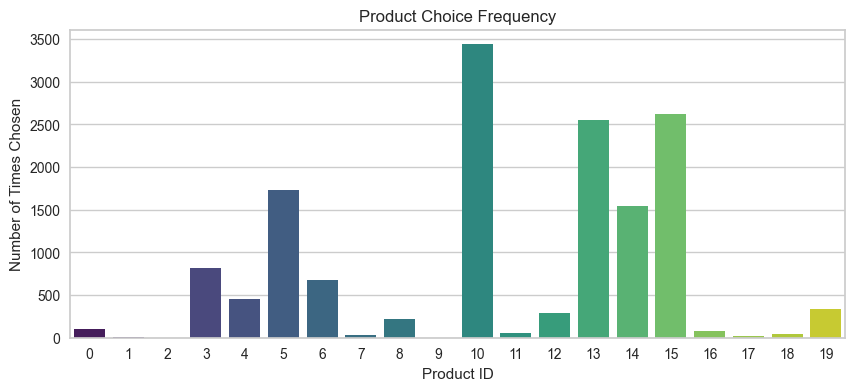

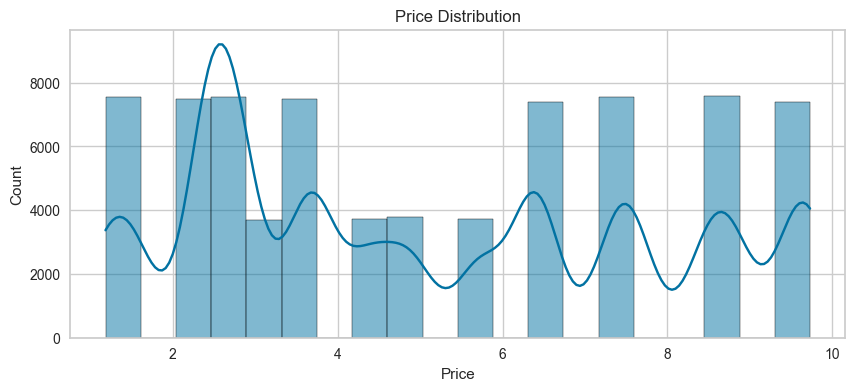

C:\Users\juani\AppData\Local\Temp\ipykernel_25732\4031541323.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["choice"], y=df["price"], palette="Set2")


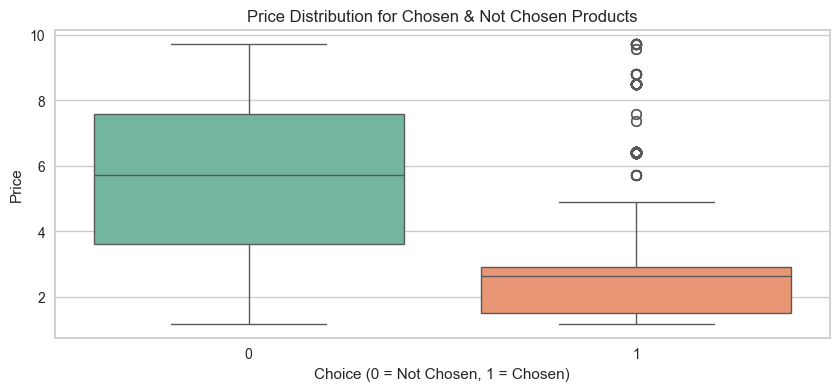

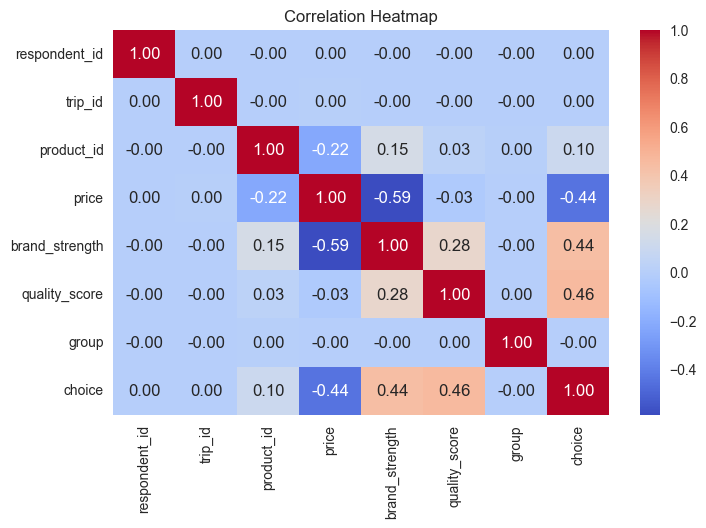

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 1. BASIC SUMMARY ###
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

### 2. DESCRIPTIVE STATISTICS ###
print("\nDescriptive Statistics:\n", df.describe())

### 3. CHOICE ANALYSIS ###
# How many times each product was chosen
choice_counts = df[df['choice'] == 1]['product_id'].value_counts().sort_index()
plt.figure(figsize=(10, 4))
sns.barplot(x=choice_counts.index, y=choice_counts.values, palette="viridis")
plt.xlabel("Product ID")
plt.ylabel("Number of Times Chosen")
plt.title("Product Choice Frequency")
plt.show()

### 4. PRICE DISTRIBUTION ###
plt.figure(figsize=(10, 4))
sns.histplot(df["price"], bins=20, kde=True)
plt.xlabel("Price")
plt.title("Price Distribution")
plt.show()

### 5. PRICE VS CHOICE ANALYSIS ###
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["choice"], y=df["price"], palette="Set2")
plt.xlabel("Choice (0 = Not Chosen, 1 = Chosen)")
plt.ylabel("Price")
plt.title("Price Distribution for Chosen & Not Chosen Products")
plt.show()

### 6. CORRELATION ANALYSIS ###
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


array([2.911052  , 2.40395068, 8.79558531, 1.18526045, 8.49198377,
       4.37086107, 6.38792636, 9.55642876, 3.62106226, 2.65064059,
       4.88750517, 7.3726532 , 5.72280788, 2.6364247 , 3.73818019,
       6.41003511, 7.58794548, 9.72918867, 1.52275251, 2.40416776])

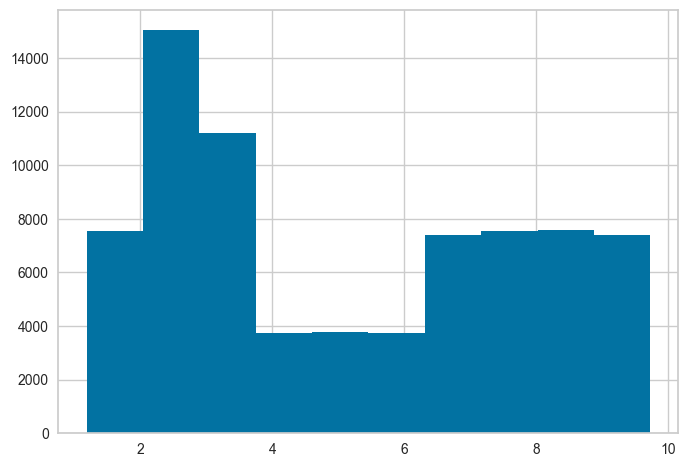

In [31]:
df.price.hist()
df.price.unique()

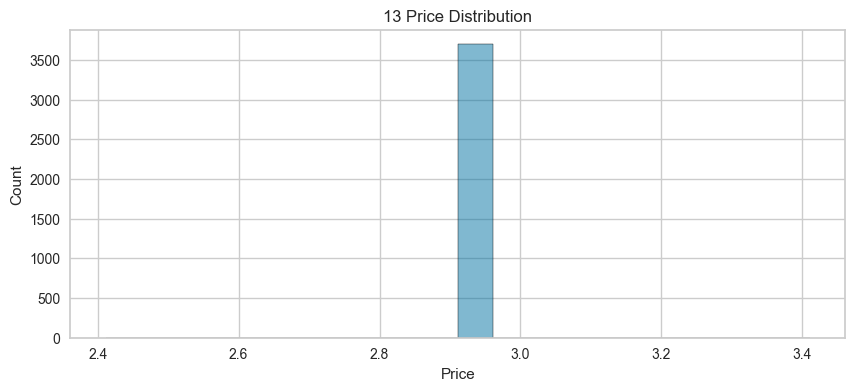

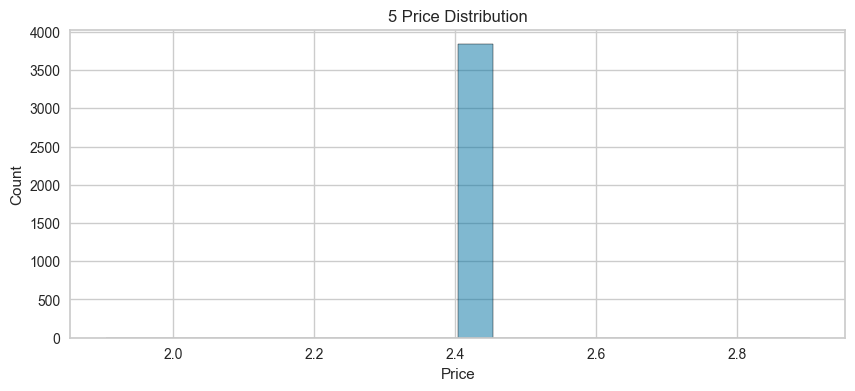

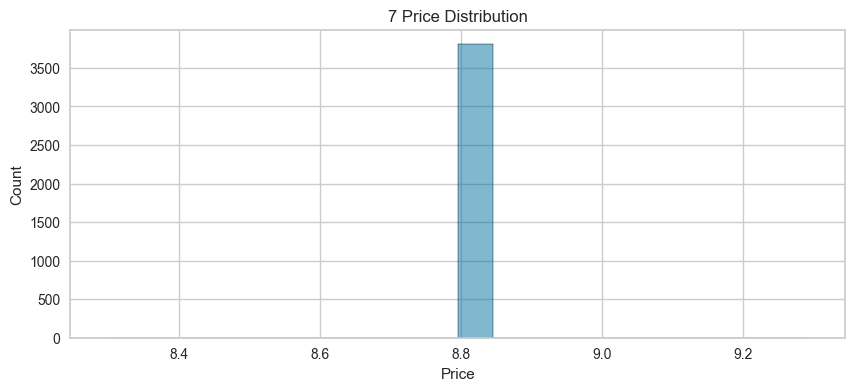

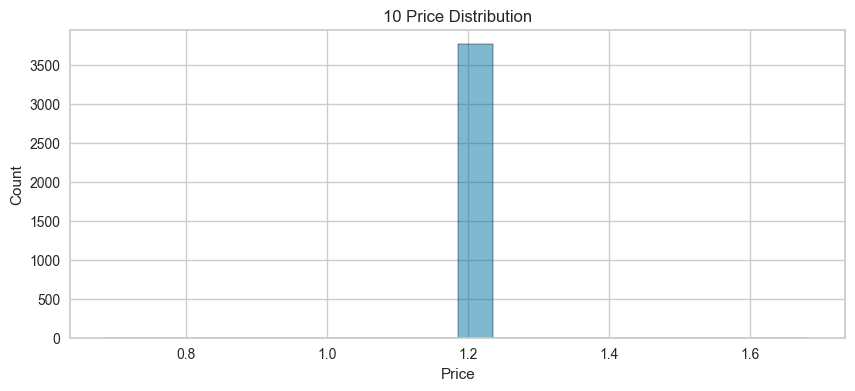

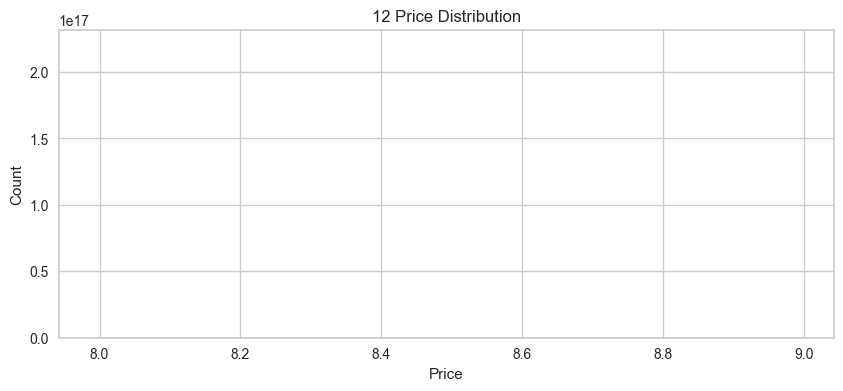

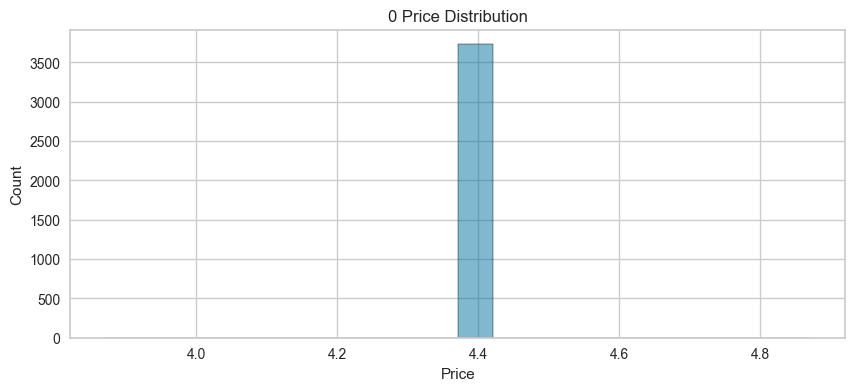

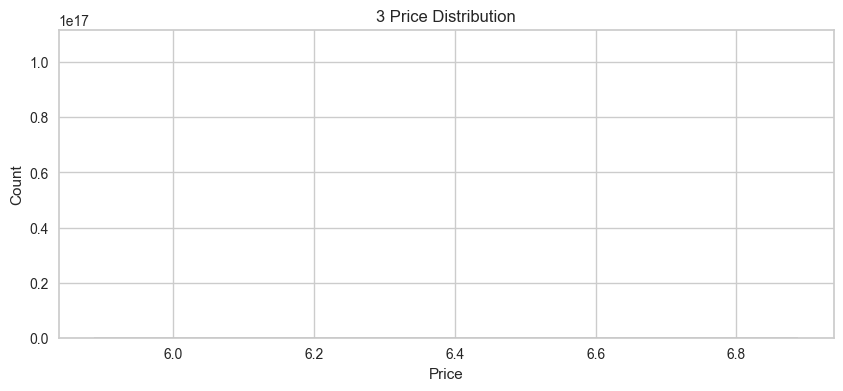

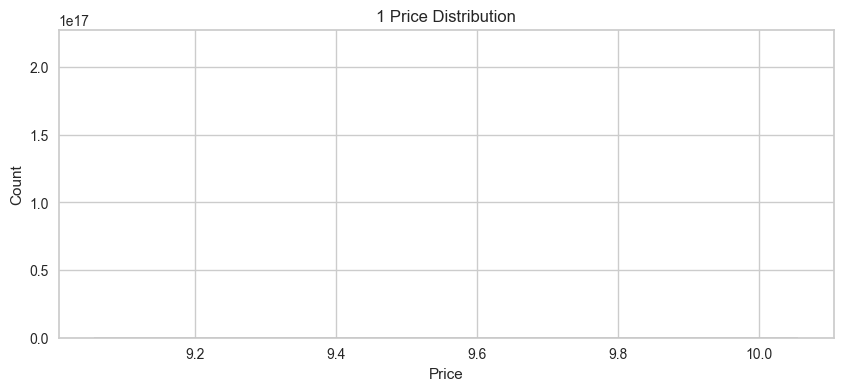

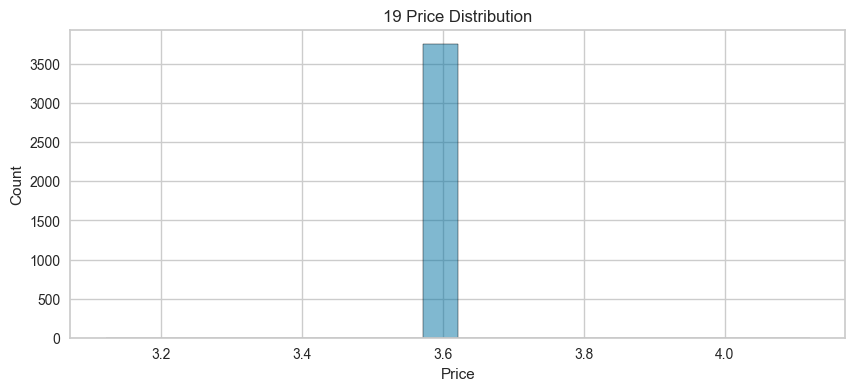

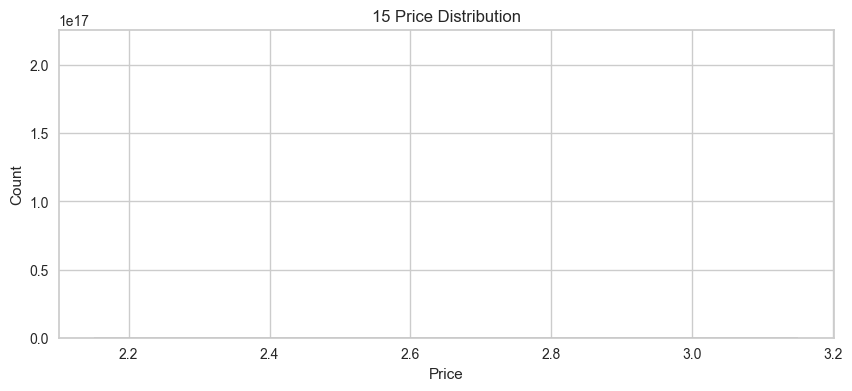

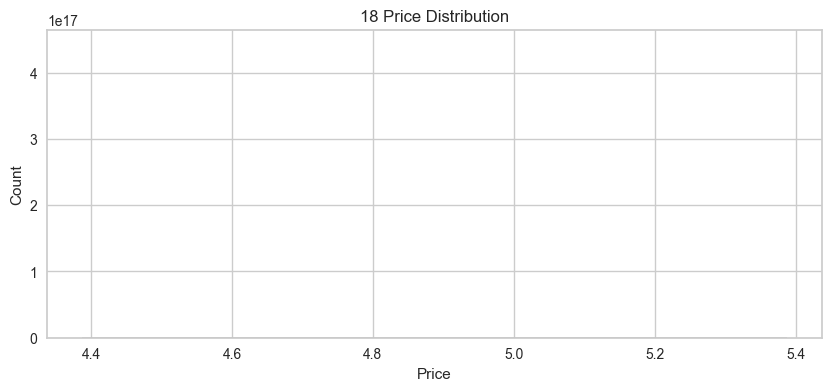

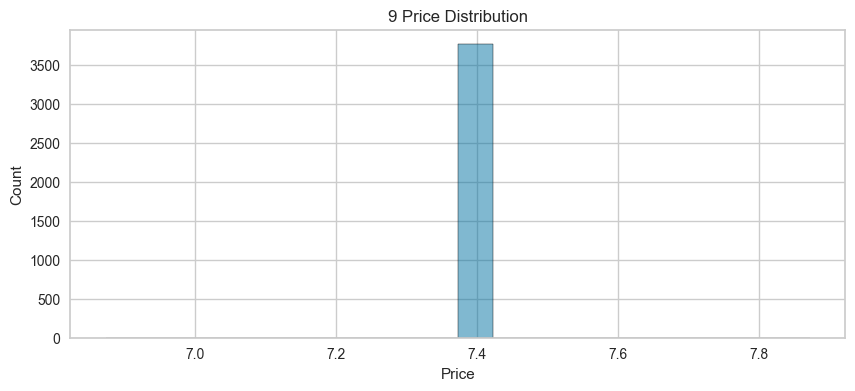

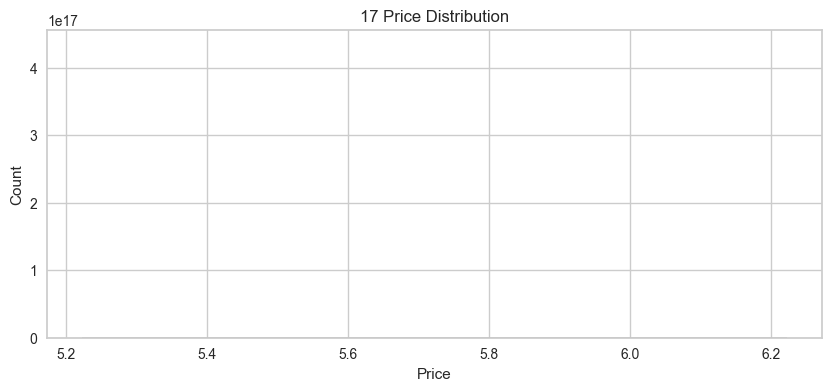

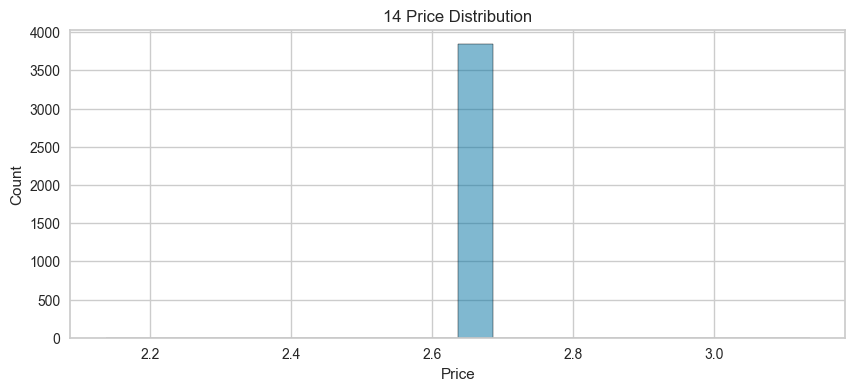

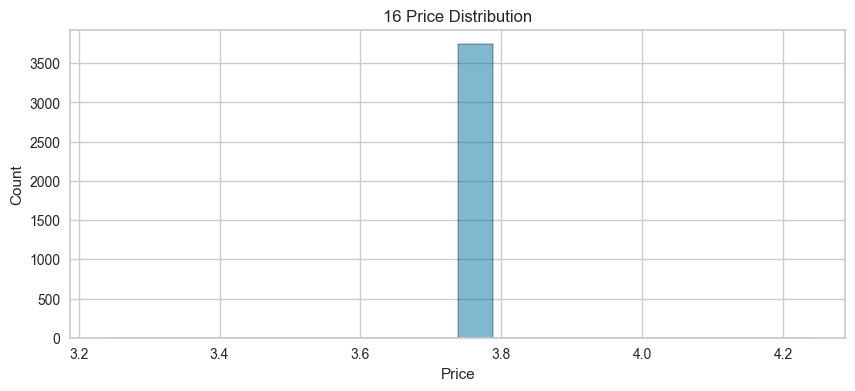

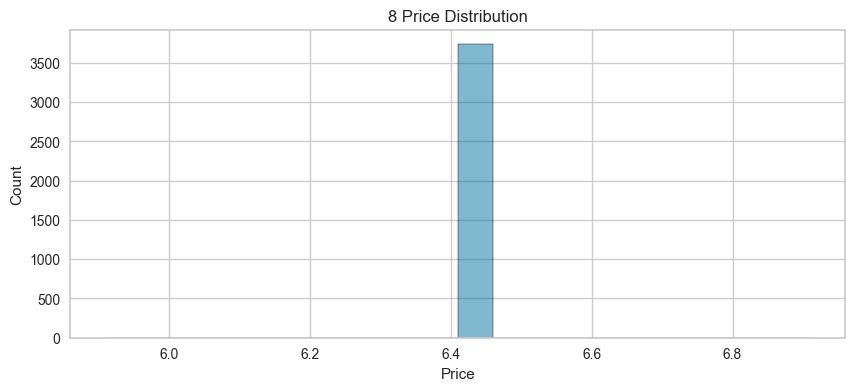

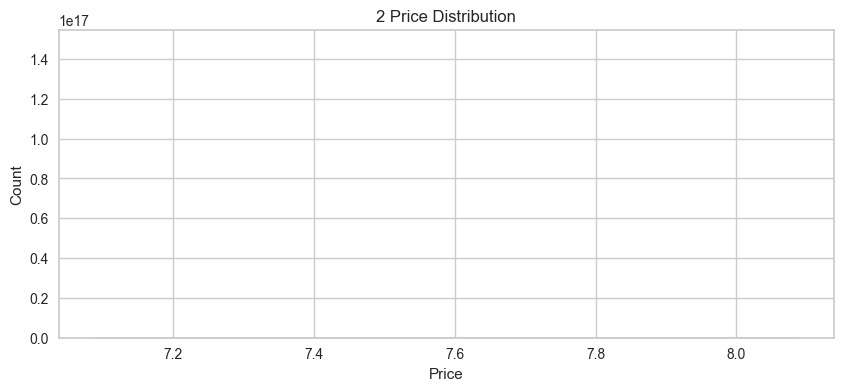

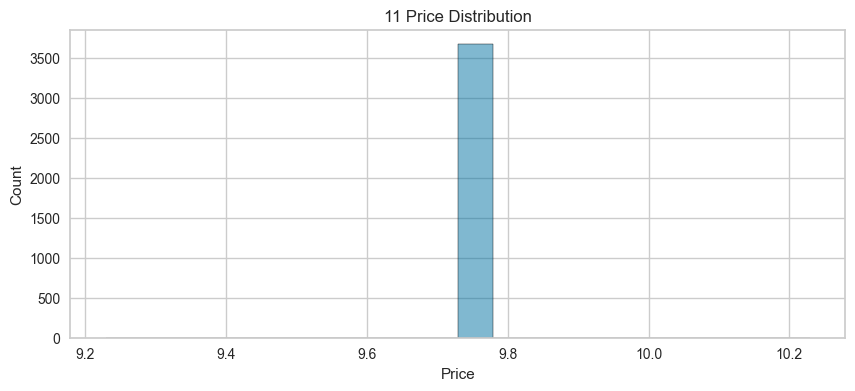

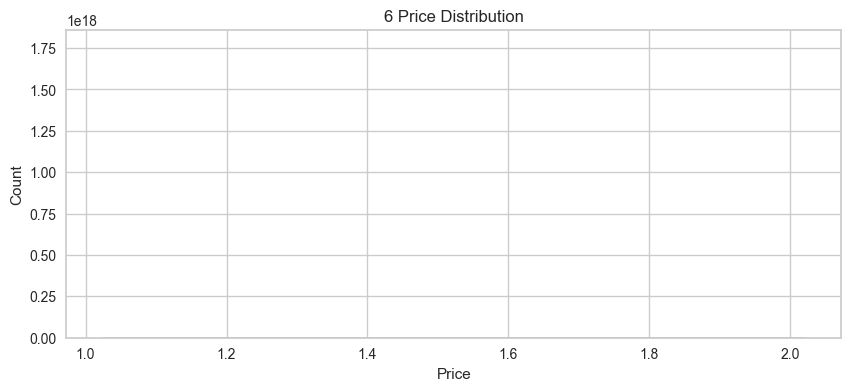

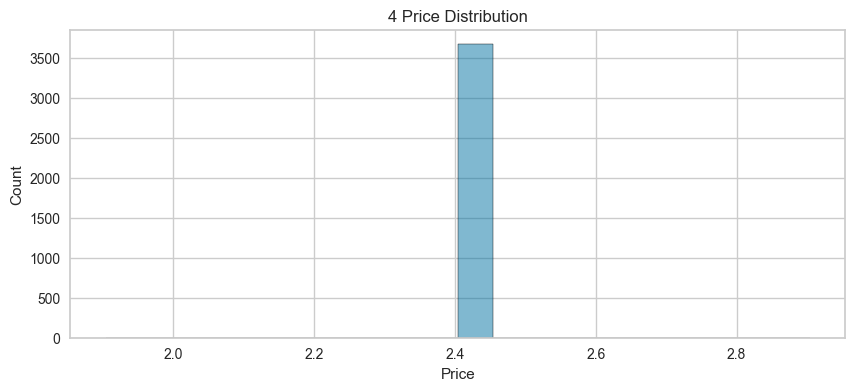

In [29]:
for prod in df.product_id.unique():
    ### 4. PRICE DISTRIBUTION ###
    temp = df[df.product_id == prod].copy()
    plt.figure(figsize=(10, 4))
    sns.histplot(temp["price"], bins=20, kde=True)
    plt.xlabel("Price")
    plt.title(f"{prod} Price Distribution")
    plt.show()

In [33]:
for col in ['product_id', 'trip_id','respondent_id']:
    df[col] = df[col].map(df[col].value_counts() / len(df))

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)  # Apply only after encoding categoric

In [35]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5).fit(df_scaled)
df['cluster'] = db.labels_

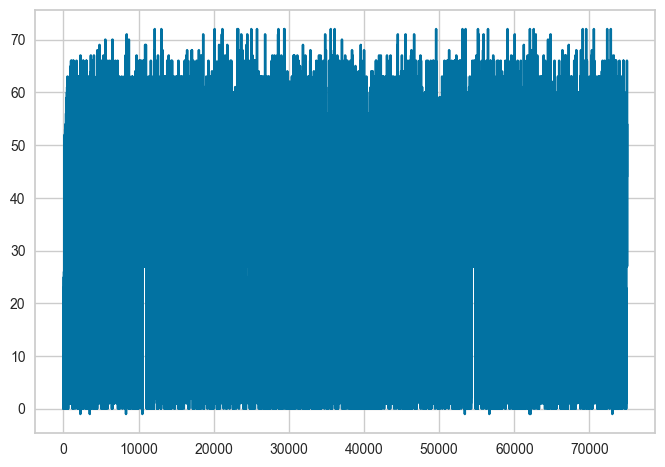

In [36]:
plt.plot(df.cluster)

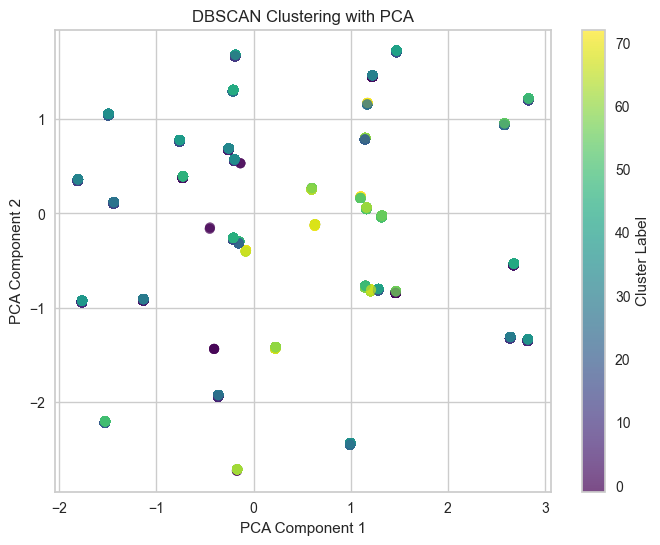

In [37]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)  # Use the scaled data

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(label="Cluster Label")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Clustering with PCA")
plt.show()

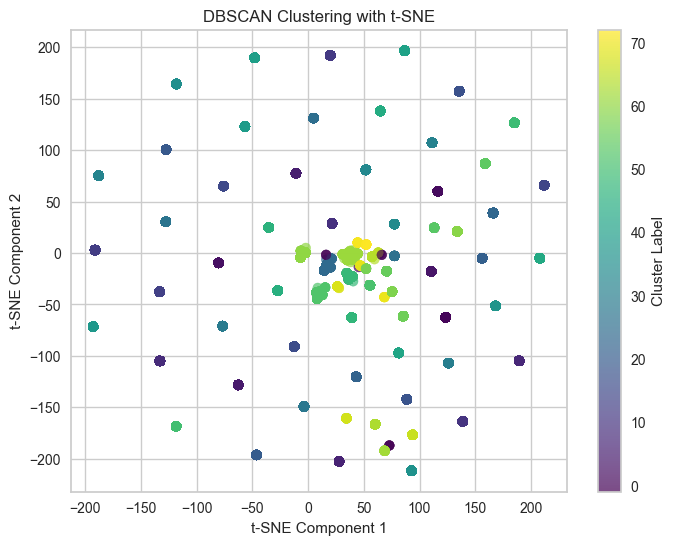

In [38]:
from sklearn.manifold import TSNE

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42)
df_tsne = tsne.fit_transform(df_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(df_tsne[:, 0], df_tsne[:, 1], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(label="Cluster Label")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("DBSCAN Clustering with t-SNE")
plt.show()


---

In [58]:
df

,respondent_id,trip_id,product_id,price,brand_strength,quality_score,group,choice
0,0,0,13,2.911052,0.948886,4.579309,0,0
1,0,0,5,2.403951,0.785176,3.650089,0,0
2,0,0,7,8.795585,0.514234,3.080272,0,0
3,0,0,10,1.185260,0.607545,4.878339,0,1
4,0,0,12,8.491984,0.065052,4.757996,0,0
...,...,...,...,...,...,...,...,...
74995,1499,9,5,2.403951,0.785176,3.650089,1,1
74996,1499,9,19,3.621062,0.440152,2.301321,1,0
74997,1499,9,18,4.887505,0.684233,1.180909,1,0
74998,1499,9,8,6.410035,0.592415,3.186841,1,0


In [62]:
df.product_id.nunique()

20

In [ ]:
df = 
merged.scaled_coeff.price

-11.339612213837626

In [179]:
grouped_df.sort_values(by='index',ascending=False)

,choice,price,brand_strength,quality_score,index
product_id,,,,,
10,3438,1.2,0.6,4.9,226.102702
13,2548,2.9,0.9,4.6,215.068562
15,2620,2.7,0.8,4.7,214.588751
5,1735,2.4,0.8,3.7,177.404483
14,1540,2.6,1.0,3.4,176.573413
3,815,6.4,0.4,4.6,141.348175
12,293,8.5,0.1,4.8,105.233173
8,216,6.4,0.6,3.2,98.140261
4,455,2.4,0.5,2.0,87.988979


In [177]:
grouped_df['index'] = [merged.scaled_coeff.price * p+
                       merged.scaled_coeff.brand_strength * b+
                       merged.scaled_coeff.quality_score * q
                       for p,b,q in zip(grouped_df.price,grouped_df.brand_strength,grouped_df.quality_score)]
grouped_df

,choice,price,brand_strength,quality_score,index
product_id,,,,,
9,2,7.4,0.0,1.7,-14.916673
1,3,9.6,0.1,3.0,19.704526
17,16,5.7,0.1,1.8,15.225632
12,293,8.5,0.1,4.8,105.233173
6,682,1.5,0.2,2.2,85.892813
11,53,9.7,0.2,4.1,70.021681
2,2,7.6,0.3,1.1,-21.117239
16,78,3.7,0.3,1.4,35.283094
19,332,3.6,0.4,2.3,79.750940


In [172]:
grouped_df = df.groupby('product_id').agg({'choice': 'sum',
                              'price': 'mean',
                              'brand_strength': 'mean',
                              'quality_score': 'mean',
                              }).round(1).sort_values(by='brand_strength',ascending=True)
grouped_df 


,choice,price,brand_strength,quality_score
product_id,,,,
9,2,7.4,0.0,1.7
1,3,9.6,0.1,3.0
17,16,5.7,0.1,1.8
12,293,8.5,0.1,4.8
6,682,1.5,0.2,2.2
11,53,9.7,0.2,4.1
2,2,7.6,0.3,1.1
16,78,3.7,0.3,1.4
19,332,3.6,0.4,2.3


In [160]:
%run nested_logit.py

   product_id group  predicted_choice_prob
0           1     A               0.123658
1           2     A               0.255439
2           3     A               0.027375
3           4     A               0.083137
4           5     B               0.321224
5           6     B               0.080440
6           7     B               0.047785
7           8     B               0.060942


In [161]:
nested_predictions = pd.read_parquet('nested_predictions.parquet')
nested_predictions

,product_id,price,brand_strength,quality_score,group,const,exp_utility,group_sum_util,prob_within_group,prob_group,predicted_choice_prob
0,1,5.0,0.3,3.0,A,1.0,0.080772,0.319807,0.252565,0.489609,0.123658
1,2,7.0,0.6,4.5,A,1.0,0.166850,0.319807,0.521720,0.489609,0.255439
2,3,6.5,0.2,2.5,A,1.0,0.017881,0.319807,0.055913,0.489609,0.027375
3,4,8.0,0.8,4.0,A,1.0,0.054304,0.319807,0.169802,0.489609,0.083137
4,5,4.5,0.5,3.5,B,1.0,0.209820,0.333382,0.629368,0.510391,0.321224
5,6,6.2,0.4,3.2,B,1.0,0.052543,0.333382,0.157605,0.510391,0.080440
6,7,9.1,0.7,4.1,B,1.0,0.031212,0.333382,0.093624,0.510391,0.047785
7,8,5.8,0.3,2.8,B,1.0,0.039807,0.333382,0.119404,0.510391,0.060942
